In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os, csv
from datetime import datetime
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

Parte_1 PREPROCESAMIENTO DE DATOS

Caracteristicas: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Tamano de X: (506, 13)
Tamano de Y: (506, 1)


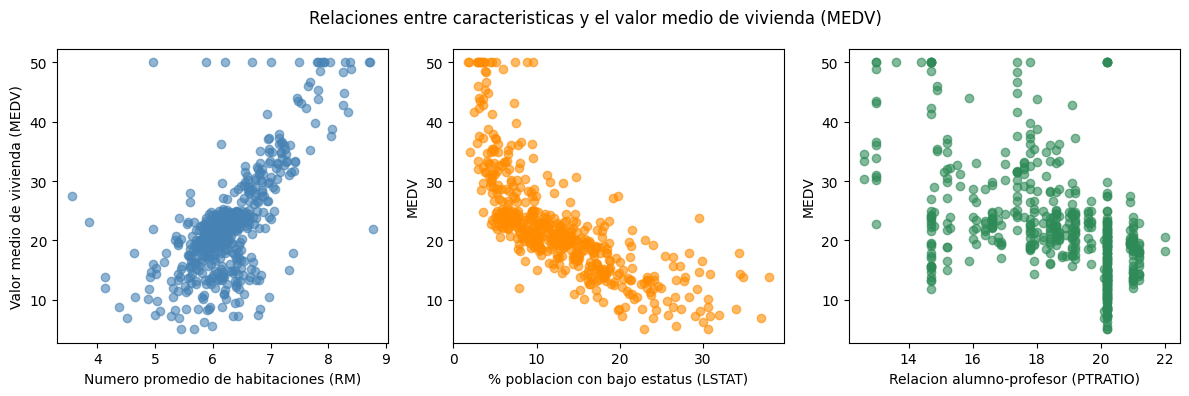

In [ ]:
# ======================================================
# PARTE 1: PREPROCESAMIENTO DE DATOS
# ======================================================
print("Parte_1 PREPROCESAMIENTO DE DATOS\n")

# Cargamos el dataset Boston Housing desde OpenML
boston = fetch_openml(name="boston", version=1, as_frame=True)
X = boston.data
Y = boston.target.astype(float).values.reshape(-1, 1)  # Aseguramos que Y sea un vector columna

print("Caracteristicas:", X.columns.tolist())
print("Tamano de X:", X.shape)
print("Tamano de Y:", Y.shape)

# Dividir dataset en entrenamiento (80%) y prueba (20%)
X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

# Normalizacion de las caracteristicas entre 0 y 1 (Min-Max)
escalador = MinMaxScaler()
X_entrenamiento = escalador.fit_transform(X_entrenamiento)
X_prueba = escalador.transform(X_prueba)

# ---- Visualizacion exploratoria ---- #
# Graficar relaciones de algunas caracteristicas importantes vs MEDV
plt.figure(figsize=(12, 4))

# 1. RM vs MEDV (numero promedio de habitaciones)
plt.subplot(1, 3, 1)
plt.scatter(boston.data["RM"], boston.target.astype(float), color="steelblue", alpha=0.6)
plt.xlabel("Numero promedio de habitaciones (RM)")
plt.ylabel("Valor medio de vivienda (MEDV)")

# 2. LSTAT vs MEDV (porcentaje de poblacion de bajo estatus)
plt.subplot(1, 3, 2)
plt.scatter(boston.data["LSTAT"], boston.target.astype(float), color="darkorange", alpha=0.6)
plt.xlabel("% poblacion con bajo estatus (LSTAT)")
plt.ylabel("MEDV")

# 3. PTRATIO vs MEDV (relacion alumno-profesor)
plt.subplot(1, 3, 3)
plt.scatter(boston.data["PTRATIO"], boston.target.astype(float), color="seagreen", alpha=0.6)
plt.xlabel("Relacion alumno-profesor (PTRATIO)")
plt.ylabel("MEDV")

plt.suptitle("Relaciones entre caracteristicas y el valor medio de vivienda (MEDV)")
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================
# PARTE 2: DISEÑO DE LA RED NEURONAL (hecha a mano)
# ======================================================
print("Parte_2 DISENO DE LA RED NEURONAL (hecha a mano)\n")

# ---- Definicion de la clase Capa ---- #
class Capa:
    def __init__(self, entradas, salidas, funcion_activacion):
        self.funcion_activacion = funcion_activacion
        # Inicializacion Xavier/He para pesos
        limite = np.sqrt(6 / (entradas + salidas))
        self.W = np.random.uniform(-limite, limite, (entradas, salidas))
        self.b = np.zeros((1, salidas))

# ---- Funciones de activacion ---- #
def derivada_relu(x):
    return np.where(x > 0, 1, 0)

relu = (
    lambda x: x * (x > 0),   # f(x) = ReLU
    derivada_relu            # f'(x) = derivada de ReLU
)

lineal = (
    lambda x: x,             # f(x) lineal
    lambda x: np.ones_like(x) # f'(x) = 1
)

# ---- Funcion de costo MSE (Mean Squared Error) ---- #
def mse(Y_pred, Y_real):
    # Calcula el error cuadratico medio
    x = np.mean((Y_pred - Y_real) ** 2)
    # Derivada del error para backpropagation
    y = (Y_pred - Y_real)
    return (x, y)

# ---- Funcion de entrenamiento de la red ---- #
def entrenamiento(X, Y, red, lr=0.01):
    salida = [X]    # lista para almacenar salidas de cada capa (forward pass)

    # Forward pass
    for capa in red:
        z = salida[-1] @ capa.W + capa.b
        a = capa.funcion_activacion[0](z)
        salida.append(a)

    # Backpropagation
    indices = list(range(len(salida) - 1))[::-1]
    delta = []
    for idx in indices:
        a = salida[idx + 1]
        if idx == indices[0]:  # capa de salida
            x = mse(a, Y)[1] * red[idx].funcion_activacion[1](a)
            delta.append(x)
        else:  # capas ocultas
            x = delta[-1] @ W_temp * red[idx].funcion_activacion[1](a)
            delta.append(x)
        W_temp = red[idx].W.T

        # Actualizacion de pesos y bias (Gradient Descent)
        red[idx].b -= np.mean(delta[-1], axis=0, keepdims=True) * lr
        red[idx].W -= salida[idx].T @ delta[-1] * lr

    return salida[-1]

# ---- Funcion para prediccion ---- #
def predecir(X, red):
    salida = X
    for capa in red:
        z = salida @ capa.W + capa.b
        salida = capa.funcion_activacion[0](z)
    return salida


Parte_2 DISENO DE LA RED NEURONAL (hecha a mano)



In [ ]:
# ======================================================
# PARTE 2.1: MANEJO DE PESOS Y REGISTRO ACUMULADO
# ======================================================
print("Parte_2.1 MANEJO DE PESOS Y REGISTRO ACUMULADO\n")

ARCHIVO_PESOS = "pesos_guardados_boston.npz"
ARCHIVO_REGISTRO = "registro_entrenamiento.csv"
UMBRAL_CAMBIO = 1e-5
PACIENTE = 10  # numero de epocas sin mejora para detener entrenamiento

neuronas = [X_entrenamiento.shape[1], 13, 1]
funciones_activacion = [relu, lineal]
red_neuronal = []

# ----- Cargar pesos previos si existen ----- #
usar_pesos_guardados = False
if os.path.exists(ARCHIVO_PESOS):
    respuesta = input("Deseas usar los pesos guardados? (s/n): ").lower()
    if respuesta == 's':
        usar_pesos_guardados = True
        data = np.load(ARCHIVO_PESOS)
        for i in range(len(neuronas) - 1):
            capa = Capa(neuronas[i], neuronas[i + 1], funciones_activacion[i])
            capa.W = data[f"W{i}"]
            capa.b = data[f"b{i}"]
            red_neuronal.append(capa)
        print("Pesos cargados desde archivo.")
else:
    print("No se encontraron pesos previos. Se usaran valores aleatorios.")

# Si no cargamos pesos, los inicializamos nuevos
if not usar_pesos_guardados:
    for i in range(len(neuronas) - 1):
        red_neuronal.append(Capa(neuronas[i], neuronas[i + 1], funciones_activacion[i]))
    print("Pesos inicializados aleatoriamente.")


Parte_2.1 MANEJO DE PESOS Y REGISTRO ACUMULADO

No se encontraron pesos previos. Se usaran valores aleatorios.
Pesos inicializados aleatoriamente.


In [ ]:
# ======================================================
# PARTE 3.1: ENTRENAMIENTO AUTOMATICO CON PARADA
# ======================================================
print("Parte_3.1 ENTRENAMIENTO AUTOMATICO CON PARADA\n")

error = []          # lista para almacenar errores de cada epoca
sin_mejora = 0      # contador de epocas sin mejora significativa
mejor_error = np.inf
epoca = 0

while True:
    Y_pred = entrenamiento(X_entrenamiento, Y_entrenamiento, red_neuronal, lr=0.000059)
    temp_error = mse(Y_pred, Y_entrenamiento)[0]
    error.append(temp_error)

    if epoca % 5 == 0:
        print(f"Epoca {epoca+1}, Error: {temp_error:.6f}")

    # Parada temprana si no hay mejora
    if mejor_error - temp_error < UMBRAL_CAMBIO:
        sin_mejora += 1
        if sin_mejora >= PACIENTE:
            print(f"\nEntrenamiento detenido: error cambio menos de {UMBRAL_CAMBIO} durante {PACIENTE} epocas.")
            break
    else:
        mejor_error = temp_error
        sin_mejora = 0

    epoca += 1
    if epoca > 2000:  # limite maximo de epocas
        print("Limite de epocas alcanzado.")
        break

Parte_3.1 ENTRENAMIENTO AUTOMATICO CON PARADA

Epoca 1, Error: 609.921793
Epoca 6, Error: 108.836746
Epoca 11, Error: 68.902647
Epoca 16, Error: 50.963261
Epoca 21, Error: 43.919861
Epoca 26, Error: 39.694899
Epoca 31, Error: 36.327738
Epoca 36, Error: 33.510271
Epoca 41, Error: 31.221025
Epoca 46, Error: 29.382217
Epoca 51, Error: 27.834214
Epoca 56, Error: 26.510193
Epoca 61, Error: 25.367133
Epoca 66, Error: 24.294552
Epoca 71, Error: 23.519870
Epoca 76, Error: 23.919326
Epoca 81, Error: 30.810597

Entrenamiento detenido: error cambio menos de 1e-05 durante 10 epocas.


In [ ]:
# ======================================================
# PARTE 3.2: GUARDADO DE PESOS Y REGISTRO
# ======================================================
print("Parte_3.2 GUARDADO DE PESOS Y REGISTRO\n")

# Guardar pesos en archivo npz
np.savez(ARCHIVO_PESOS, **{f"W{i}": c.W for i, c in enumerate(red_neuronal)},
                        **{f"b{i}": c.b for i, c in enumerate(red_neuronal)})
print(f"Pesos guardados en '{ARCHIVO_PESOS}'")

# Registrar epoca y errores en CSV
epoca_actual = epoca + 1
loss_final = float(error[-1])
loss_minimo = float(min(error))

total_epocas_previas = 0
if os.path.exists(ARCHIVO_REGISTRO):
    with open(ARCHIVO_REGISTRO, "r", newline='') as f:
        reader = csv.DictReader(f)
        for fila in reader:
            total_epocas_previas += int(fila["EpocasEntrenadas"])
total_epocas_nuevo = total_epocas_previas + epoca_actual

archivo_existe = os.path.exists(ARCHIVO_REGISTRO)
with open(ARCHIVO_REGISTRO, "a", newline='') as f:
    campos = ["Fecha", "PesosUsados", "EpocasEntrenadas", "LossFinal", "LossMinimo", "TotalEpocasAcumuladas"]
    writer = csv.DictWriter(f, fieldnames=campos)
    if not archivo_existe:
        writer.writeheader()
    writer.writerow({
        "Fecha": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "PesosUsados": "Guardados" if usar_pesos_guardados else "Aleatorios",
        "EpocasEntrenadas": epoca_actual,
        "LossFinal": f"{loss_final:.6f}",
        "LossMinimo": f"{loss_minimo:.6f}",
        "TotalEpocasAcumuladas": total_epocas_nuevo
    })

print(f"Registro actualizado en '{ARCHIVO_REGISTRO}'")
print(f"Epocas entrenadas esta sesion: {epoca_actual}")
print(f"Epocas acumuladas totales: {total_epocas_nuevo}")


Parte_3.2 GUARDADO DE PESOS Y REGISTRO

Pesos guardados en 'pesos_guardados_boston.npz'
Registro actualizado en 'registro_entrenamiento.csv'
Epocas entrenadas esta sesion: 83
Epocas acumuladas totales: 83


Parte_3.3 EVALUACION FINAL



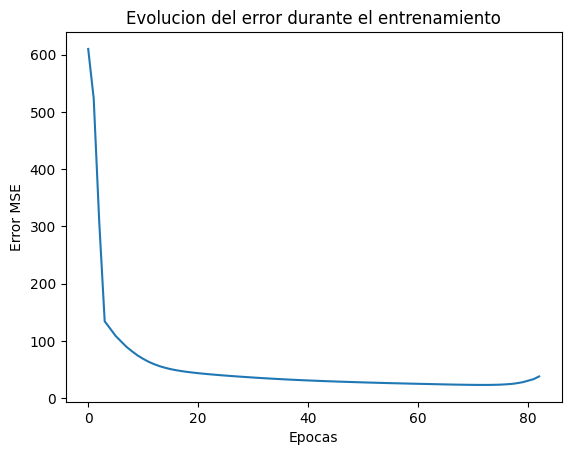


MSE en entrenamiento: 38.259550
MSE en prueba: 51.335329


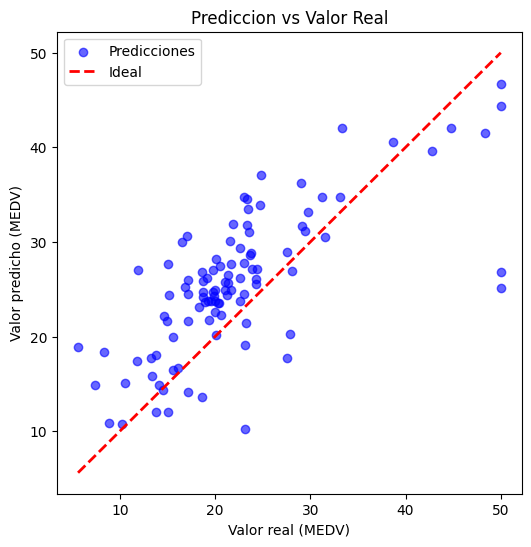

In [ ]:
# ======================================================
# PARTE 3.3: EVALUACION FINAL
# ======================================================
print("Parte_3.3 EVALUACION FINAL\n")

# Graficar evolucion del error
plt.plot(range(len(error)), error)
plt.xlabel("Epocas")
plt.ylabel("Error MSE")
plt.title("Evolucion del error durante el entrenamiento")
plt.show()

# Prediccion sobre set de prueba
Y_pred_prueba = predecir(X_prueba, red_neuronal)
mse_train = mse(Y_pred, Y_entrenamiento)[0]
mse_test = mse(Y_pred_prueba, Y_prueba)[0]

print(f"\nMSE en entrenamiento: {mse_train:.6f}")
print(f"MSE en prueba: {mse_test:.6f}")

# Grafico comparativo prediccion vs valor real
plt.figure(figsize=(6,6))
plt.scatter(Y_prueba, Y_pred_prueba, alpha=0.6, color="blue", label="Predicciones")
plt.plot([Y_prueba.min(), Y_prueba.max()], [Y_prueba.min(), Y_prueba.max()], 'r--', lw=2, label="Ideal")
plt.xlabel("Valor real (MEDV)")
plt.ylabel("Valor predicho (MEDV)")
plt.title("Prediccion vs Valor Real")
plt.legend()
plt.show()


Parte_4 REGULARIZACION L2 (Weight Decay)


INICIANDO ENTRENAMIENTO CON REGULARIZACION L2

Entrenando con L2 = 0.0

Entrenando con L2 = 0.0001

Entrenando con L2 = 0.001

Entrenando con L2 = 0.005

Mejor L2: 0.005, Error final: 27.384318
MSE en prueba con L2=0.005: 49.565181


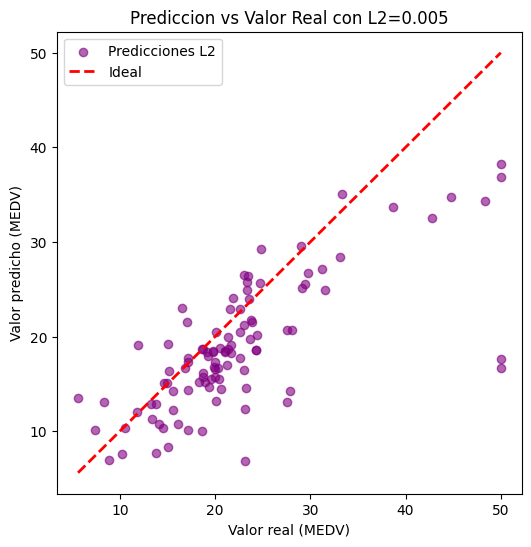

In [ ]:
# ======================================================
# PARTE 4: REGULARIZACION L2 (Weight Decay)
# ======================================================
print("Parte_4 REGULARIZACION L2 (Weight Decay)\n")

print("\nINICIANDO ENTRENAMIENTO CON REGULARIZACION L2")

# Definir valores de L2 a probar (0 = sin regularizacion, otros valores pequeños para evitar sobreajuste)
valores_l2 = [0.0, 0.0001, 0.001, 0.005]
resultados_l2 = {}

for l2_lambda in valores_l2:
    print(f"\nEntrenando con L2 = {l2_lambda}")

    # Creamos copia de la red ya entrenada sin L2 para usarla como punto de partida
    red_l2 = []
    for capa in red_neuronal:
        nueva_capa = Capa(capa.W.shape[0], capa.W.shape[1], capa.funcion_activacion)
        nueva_capa.W = capa.W.copy()
        nueva_capa.b = capa.b.copy()
        red_l2.append(nueva_capa)

    # Entrenamiento con regularizacion L2
    error_l2 = []
    sin_mejora = 0
    mejor_error = np.inf
    epoca = 0

    while True:
        # Forward pass
        salida = [X_entrenamiento]
        for capa in red_l2:
            z = salida[-1] @ capa.W + capa.b
            a = capa.funcion_activacion[0](z)
            salida.append(a)

        # Backpropagation
        indices = list(range(len(salida) - 1))[::-1]
        delta = []
        for idx in indices:
            a = salida[idx + 1]
            if idx == indices[0]:  # capa de salida
                x = mse(a, Y_entrenamiento)[1] * red_l2[idx].funcion_activacion[1](a)
                delta.append(x)
            else:  # capas ocultas
                x = delta[-1] @ W_temp * red_l2[idx].funcion_activacion[1](a)
                delta.append(x)
            W_temp = red_l2[idx].W.T

            # Gradient Descent con L2: actualizamos pesos y bias
            red_l2[idx].b -= np.mean(delta[-1], axis=0, keepdims=True) * 0.000059
            red_l2[idx].W -= (salida[idx].T @ delta[-1] + l2_lambda * red_l2[idx].W) * 0.000059

        # Guardar error de la epoca
        Y_pred_l2 = salida[-1]
        temp_error = mse(Y_pred_l2, Y_entrenamiento)[0]
        error_l2.append(temp_error)

        # Parada temprana
        if mejor_error - temp_error < UMBRAL_CAMBIO:
            sin_mejora += 1
            if sin_mejora >= PACIENTE:
                break
        else:
            mejor_error = temp_error
            sin_mejora = 0

        epoca += 1
        if epoca > 2000:  # limite de epocas
            break

    # Guardar resultados de esta configuracion L2
    resultados_l2[l2_lambda] = (error_l2, red_l2)

# Seleccionamos el mejor valor de L2 segun error final mas bajo
mejor_l2 = min(resultados_l2, key=lambda k: resultados_l2[k][0][-1])
mejor_red_l2 = resultados_l2[mejor_l2][1]
error_final_l2 = resultados_l2[mejor_l2][0]

print(f"\nMejor L2: {mejor_l2}, Error final: {error_final_l2[-1]:.6f}")

# Evaluacion de la red regularizada en set de prueba
Y_pred_l2_prueba = predecir(X_prueba, mejor_red_l2)
mse_test_l2 = mse(Y_pred_l2_prueba, Y_prueba)[0]
print(f"MSE en prueba con L2={mejor_l2}: {mse_test_l2:.6f}")

# Graficar predicciones vs valores reales con L2
plt.figure(figsize=(6,6))
plt.scatter(Y_prueba, Y_pred_l2_prueba, alpha=0.6, color="purple", label="Predicciones L2")
plt.plot([Y_prueba.min(), Y_prueba.max()], [Y_prueba.min(), Y_prueba.max()], 'r--', lw=2, label="Ideal")
plt.xlabel("Valor real (MEDV)")
plt.ylabel("Valor predicho (MEDV)")
plt.title(f"Prediccion vs Valor Real con L2={mejor_l2}")
plt.legend()
plt.show()

Parte_5 EXPERIMENTACION CON HIPERPARAMETROS


INICIANDO EXPERIMENTACION CON HIPERPARAMETROS

Entrenando con lr=5e-05, neuronas ocultas=10
Error final entrenamiento: 19.989138

Entrenando con lr=5e-05, neuronas ocultas=13
Error final entrenamiento: 23.494573

Entrenando con lr=5e-05, neuronas ocultas=16
Error final entrenamiento: 20.490191

Entrenando con lr=0.0001, neuronas ocultas=10


/tmp/ipykernel_22543/2698742216.py:43: RuntimeWarning: overflow encountered in matmul
  z = salida[-1] @ capa.W + capa.b
/tmp/ipykernel_22543/2698742216.py:62: RuntimeWarning: invalid value encountered in matmul
  red[idx].W -= salida[idx].T @ delta[-1] * lr


Error final entrenamiento: nan

Entrenando con lr=0.0001, neuronas ocultas=13
Error final entrenamiento: nan

Entrenando con lr=0.0001, neuronas ocultas=16
Error final entrenamiento: nan

Entrenando con lr=0.0005, neuronas ocultas=10


/tmp/ipykernel_22543/2698742216.py:32: RuntimeWarning: overflow encountered in square
  x = np.mean((Y_pred - Y_real) ** 2)
/tmp/ipykernel_22543/2698742216.py:56: RuntimeWarning: overflow encountered in matmul
  x = delta[-1] @ W_temp * red[idx].funcion_activacion[1](a)


Error final entrenamiento: nan

Entrenando con lr=0.0005, neuronas ocultas=13
Error final entrenamiento: nan

Entrenando con lr=0.0005, neuronas ocultas=16
Error final entrenamiento: nan

Mejor combinacion: lr=5e-05, neuronas ocultas=10, Error final=19.989138
MSE en prueba con mejor configuracion: 35.501961


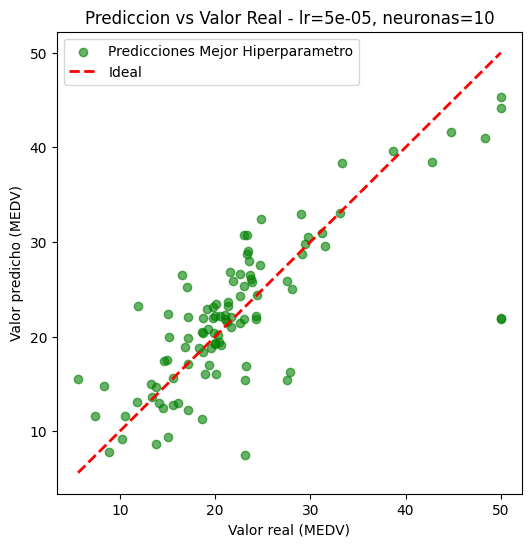

In [ ]:
# ======================================================
# PARTE 5: EXPERIMENTACION CON HIPERPARAMETROS
# ======================================================
print("Parte_5 EXPERIMENTACION CON HIPERPARAMETROS\n")

print("\nINICIANDO EXPERIMENTACION CON HIPERPARAMETROS")

# Definir combinaciones de tasas de aprendizaje y numero de neuronas en capa oculta
tasas_aprendizaje = [0.00005, 0.0001, 0.0005]
neuronas_oculta = [10, 13, 16]
resultados_hiper = {}

for lr in tasas_aprendizaje:
    for n_oculta in neuronas_oculta:
        print(f"\nEntrenando con lr={lr}, neuronas ocultas={n_oculta}")

        # Configurar red neuronal con esta combinacion
        neuronas_exp = [X_entrenamiento.shape[1], n_oculta, 1]
        red_exp = []
        for i in range(len(neuronas_exp) - 1):
            red_exp.append(Capa(neuronas_exp[i], neuronas_exp[i + 1], funciones_activacion[i]))

        # Entrenamiento sin L2 para evaluar solo efecto de hiperparametros
        error_exp = []
        sin_mejora = 0
        mejor_error = np.inf
        epoca = 0

        while True:
            Y_pred_exp = entrenamiento(X_entrenamiento, Y_entrenamiento, red_exp, lr=lr)
            temp_error = mse(Y_pred_exp, Y_entrenamiento)[0]
            error_exp.append(temp_error)

            # Parada temprana
            if mejor_error - temp_error < UMBRAL_CAMBIO:
                sin_mejora += 1
                if sin_mejora >= PACIENTE:
                    break
            else:
                mejor_error = temp_error
                sin_mejora = 0

            epoca += 1
            if epoca > 2000:
                break

        # Guardar resultados de esta combinacion de hiperparametros
        resultados_hiper[(lr, n_oculta)] = (error_exp, red_exp)
        print(f"Error final entrenamiento: {error_exp[-1]:.6f}")

# Seleccionar mejor combinacion de hiperparametros segun error final
mejor_hp = min(resultados_hiper, key=lambda k: resultados_hiper[k][0][-1])
mejor_red_hp = resultados_hiper[mejor_hp][1]
error_final_hp = resultados_hiper[mejor_hp][0]

print(f"\nMejor combinacion: lr={mejor_hp[0]}, neuronas ocultas={mejor_hp[1]}, Error final={error_final_hp[-1]:.6f}")

# Evaluacion en set de prueba
Y_pred_hp_prueba = predecir(X_prueba, mejor_red_hp)
mse_test_hp = mse(Y_pred_hp_prueba, Y_prueba)[0]
print(f"MSE en prueba con mejor configuracion: {mse_test_hp:.6f}")

# Graficar predicciones vs valores reales con mejor configuracion
plt.figure(figsize=(6,6))
plt.scatter(Y_prueba, Y_pred_hp_prueba, alpha=0.6, color="green", label="Predicciones Mejor Hiperparametro")
plt.plot([Y_prueba.min(), Y_prueba.max()], [Y_prueba.min(), Y_prueba.max()], 'r--', lw=2, label="Ideal")
plt.xlabel("Valor real (MEDV)")
plt.ylabel("Valor predicho (MEDV)")
plt.title(f"Prediccion vs Valor Real - lr={mejor_hp[0]}, neuronas={mejor_hp[1]}")
plt.legend()
plt.show()

In [12]:
import numpy as np
data = np.load('pesos_guardados_boston.npz')
print("Capas guardadas:", data.files)
print("Forma de W0 (Capa Oculta):", data['W0'].shape)
print("Forma de W1 (Capa Salida):", data['W1'].shape)

Capas guardadas: ['W0', 'W1', 'b0', 'b1']
Forma de W0 (Capa Oculta): (13, 13)
Forma de W1 (Capa Salida): (13, 1)
